<a href="https://colab.research.google.com/github/sridharlellapalli-star/AIAgenticAPPExercise/blob/main/23May26_Lead_Generation_Business_Automation_SessionV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture

!pip install langchain langchain_groq langgraph python-dotenv langchain-community duckduckgo-search

In [ ]:
from google.colab import userdata
from langchain_groq import ChatGroq

# Get the Groq API key from Colab secrets
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
llm = ChatGroq(model="llama-3.1-8b-instant", groq_api_key=GROQ_API_KEY)

In [ ]:
import os, json

from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Literal

from langchain_groq import ChatGroq
from pydantic import BaseModel
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
class LeadState(TypedDict):
  #Input
  lead_id: str
  raw_data: dict            # {name, company, email, source, industry}
  # Set by Enricher Agent
  enricher_data:dict        # {linkedin_url, company_size, funding, tech_stack}
  # Set by BANT scorer
  bant_scores: dict
  total_score: int
  segment: Literal["hot", "warm", "cold"]
  # Set by Outreach Drafter
  draft_email: str
  # Set by CRM Writer
  crm_log:dict

In [ ]:
# ── Sample leads for testing ─────────────────────────────────────

sample_leads = [
    {"lead_id": "L001", "raw_data": {
        "name": "Priya Mehta", "company": "FinEdge Solutions",
        "email": "priya@finedge.io", "source": "enterprise_form",
        "industry": "FinTech", "company_size": "500+"
    }},
    {"lead_id": "L002", "raw_data": {
        "name": "Arjun Kapoor", "company": "KapoorStartup",
        "email": "ak@startup.com", "source": "webinar",
        "industry": "EdTech", "company_size": "10-50"
    }},
    {"lead_id": "L003", "raw_data": {
        "name": "Sarah Chen", "title": "Director of Marketing", "company": "Global Innovations",
        "email": "sarah.c@globalinnovations.com", "source": "webinar",
        "industry": "FinTech", "company_size": "500+"
    }},
    {"lead_id": "L004", "raw_data": {
        "name": "David Lee", "title": "CTO", "company": "InnovateTech Inc.",
        "email": "david.l@innovatetech.com", "source": "enterprise_form",
        "industry": "SaaS", "company_size": "1000+"
    }},
    {"lead_id": "L005", "raw_data": {
        "name": "Emily White", "company": "Local Bakery",
        "email": "emily.w@localbakery.com", "source": "website_visit",
        "industry": "Food & Beverage", "company_size": "5-10"
    }}
]

In [ ]:
def orchestrator_agent(state: LeadState) -> dict:
    """Orchestrator: logs intent, no state mutation needed here"""
    print(f"[Orchestrator] Processing lead: {state['lead_id']}")
    # Business Rule: Tag source for downstream routing
    return {}  # routing happens in conditional edge

def enricher_agent(state: LeadState) -> dict:
    """Simulates calling Clearbit / LinkedIn API for enrichment"""
    raw = state["raw_data"]
    # In production: replace with real API calls
    enriched = {
        "linkedin_url": f"linkedin.com/in/{raw['name'].lower().replace(' ','-')}",
        "company_size": raw.get("company_size", "unknown"),
        "funding_stage": "Series B",     # mock
        "tech_stack": ["Salesforce", "AWS"],  # mock
        "industry": raw.get("industry", "unknown")
    }
    print(f"  [Enricher] Enriched: {enriched}")
    return {"enriched_data": enriched}

def fast_track_agent(state: LeadState) -> dict:
    """Enterprise leads: skip third-party enrichment, use provided data"""
    raw = state["raw_data"]
    enriched = {
        "company_size": raw.get("company_size", "500+"),
        "funding_stage": "Public/Large",
        "tech_stack": ["SAP", "Salesforce"],
        "industry": raw.get("industry", "Enterprise")
    }
    print(f"  [FastTrack] Enterprise path — skipping external APIs")
    return {"enriched_data": enriched}

In [ ]:
class BANTOutput(BaseModel):
    budget: int     # 0-25
    authority: int  # 0-25
    need: int        # 0-25
    timing: int      # 0-25
    rationale: str

In [ ]:
def bant_scorer_agent(state: LeadState) -> dict:
    """LLM-powered BANT scoring with structured output"""
    enriched = state.get("enriched_data", {})
    raw = state["raw_data"]
    prompt = f"""
    Score this lead on BANT criteria (each 0-25, total 100):
    Lead: {json.dumps(raw)}
    Enriched: {json.dumps(enriched)}
    SCORING RULES (business rules encoded here):
    - Budget 20+: company_size > 200 employees OR funding Series B+
    - Authority 20+: title contains VP/Director/CTO/CEO or direct form signup
    - Need 20+: industry match (FinTech, SaaS, Enterprise)
    - Timing 20+: source = enterprise_form OR recent product search
    Return ONLY valid JSON matching: budget, authority, need, timing, rationale
    """
    structured_llm = llm.with_structured_output(BANTOutput)
    result = structured_llm.invoke([HumanMessage(content=prompt)])
    total = result.budget + result.authority + result.need + result.timing
    segment = "hot" if total >= 70 else ("warm" if total >= 45 else "cold")
    print(f"  [BANT Scorer] Score: {total}/100 → Segment: {segment}")
    return {
        "bant_scores": result.model_dump(),
        "total_score": total,
        "segment": segment
    }

def outreach_drafter_agent(state: LeadState) -> dict:
    """Drafts personalized outreach email for hot/warm leads"""
    raw, enriched = state["raw_data"], state.get("enriched_data", {})
    score = state["total_score"]
    prompt = f"""
    Write a concise, personalized B2B outreach email (max 120 words).
    Lead name: {raw['name']}, Company: {raw['company']}
    Industry: {enriched.get('industry','')}, Tech stack: {enriched.get('tech_stack',[])}
    BANT score: {score}/100. Tone: professional, value-led. No generic openers.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content
    print(f"  [Outreach] Draft generated ({len(draft)} chars)")
    return {"draft_email": draft}

def nurture_queue_agent(state: LeadState) -> dict:
    """Cold leads: enroll in 30-day drip sequence"""
    print(f"  [Nurture] Lead {state['lead_id']} added to 30-day nurture sequence")
    return {"draft_email": "[Enrolled in automated 30-day drip campaign]"}

def crm_writer_node(state: LeadState) -> dict:
    """Writes final state to CRM (mock HubSpot API)"""
    log = {
        "lead_id": state["lead_id"],
        "score": state.get("total_score", 0),
        "segment": state.get("segment", "unknown"),
        "email_queued": True,
        "status": "PROCESSED"
    }
    print(f"  [CRM Writer] Logged to CRM: {json.dumps(log)}")
    return {"crm_log": log}

In [ ]:
# ── Cell 4: Routing Functions ─────────────────────────────────────
def route_by_source(state: LeadState) -> Literal["enricher_agent", "fast_track_agent"]:
    """
    Business Rule: Enterprise form leads have enough data → fast track.
    All other sources need third-party enrichment.
    """
    source = state["raw_data"].get("source", "")
    company_size = state["raw_data"].get("company_size", "")
    if source == "enterprise_form" and "500" in company_size:
        return "fast_track_agent"
    return "enricher_agent"

def route_by_score(state: LeadState) -> Literal["outreach_drafter_agent", "warm_outreach_agent", "nurture_queue_agent"]:
    """
    Business Rule: Score ≥ 70 → immediate outreach.
    Score 45–69 → warm nurture (discovery call invite).
    Score < 45 → cold nurture (same queue, different drip).
    """
    score = state.get("total_score", 0)
    if score >= 70:
        return "outreach_drafter_agent"
    elif 45 <= score < 70:
        return "warm_outreach_agent"
    else:
        return "nurture_queue_agent"

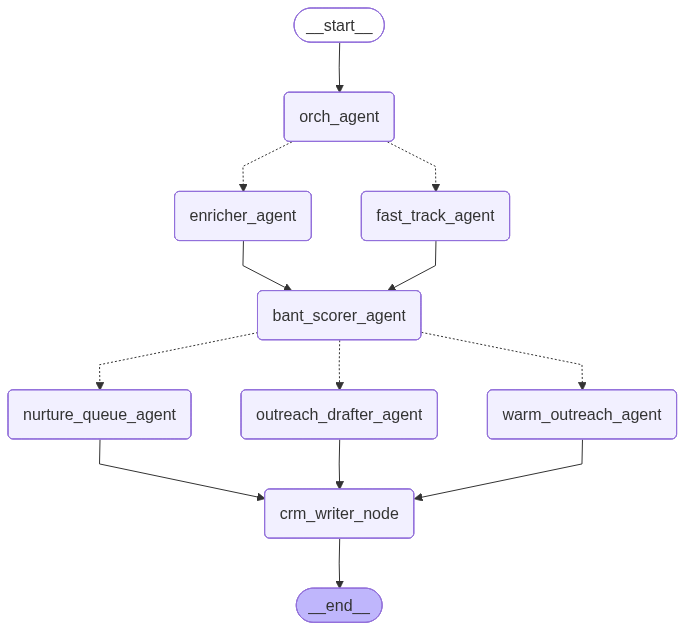

In [ ]:
# Step 5: Build Graph
graph  = StateGraph(LeadState)
# Add all nodes
graph.add_node("orch_agent", orchestrator_agent)
graph.add_node("enricher_agent", enricher_agent)
graph.add_node("fast_track_agent", fast_track_agent)
graph.add_node("bant_scorer_agent", bant_scorer_agent)
graph.add_node("outreach_drafter_agent", outreach_drafter_agent)
graph.add_node("nurture_queue_agent", nurture_queue_agent)
graph.add_node("crm_writer_node", crm_writer_node)
# Adding the warm_outreach_agent node
graph.add_node("warm_outreach_agent", nurture_queue_agent)
# Wiring the flow
graph.add_edge(START, "orch_agent")
# Conditional routing
graph.add_conditional_edges(
"orch_agent",
route_by_source,
{"enricher_agent": "enricher_agent", "fast_track_agent": "fast_track_agent"}
)
# Both enrichment path merges into BANT scorer
graph.add_edge("enricher_agent", "bant_scorer_agent")
graph.add_edge("fast_track_agent", "bant_scorer_agent")
# Conditional routing from BANT scorer
graph.add_conditional_edges(
"bant_scorer_agent",
route_by_score,
{"outreach_drafter_agent": "outreach_drafter_agent", "warm_outreach_agent": "warm_outreach_agent", "nurture_queue_agent": "nurture_queue_agent"}
)
graph.add_edge("outreach_drafter_agent", "crm_writer_node")
graph.add_edge("nurture_queue_agent", "crm_writer_node")
graph.add_edge("warm_outreach_agent", "crm_writer_node")
graph.add_edge("crm_writer_node", END)
#
app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = sample_leads[0] # Using the first sample lead as the initial state

# ── Streaming alternative (shows step-by-step execution) ─────────
print("\n\n STREAMING MODE (watch each agent fire):")
for event in app.stream(initial_state, stream_mode="updates"):
    for node, output in event.items():
        if output:
            print(f"  ↳ Node [{node}] returned: {list(output.keys())}")
        else:
            print(f"  ↳ Node [{node}] returned no state update.")



 STREAMING MODE (watch each agent fire):
[Orchestrator] Processing lead: L001
  ↳ Node [orch_agent] returned no state update.
  [FastTrack] Enterprise path — skipping external APIs
  ↳ Node [fast_track_agent] returned no state update.
  [BANT Scorer] Score: 0/100 → Segment: cold
  ↳ Node [bant_scorer_agent] returned: ['bant_scores', 'total_score', 'segment']
  [Nurture] Lead L001 added to 30-day nurture sequence
  ↳ Node [nurture_queue_agent] returned: ['draft_email']
  [CRM Writer] Logged to CRM: {"lead_id": "L001", "score": 0, "segment": "cold", "email_queued": true, "status": "PROCESSED"}
  ↳ Node [crm_writer_node] returned: ['crm_log']


In [ ]:
# Invoking the Langraph with all leads of dataset
for lead in sample_leads:
  print(f"\n{'='*60}")
  print(f"Processing: {lead['raw_data']}")
  initial_state = {
        "lead_id":       lead["lead_id"],
        "raw_data":      lead["raw_data"],
        "enriched_data": {},
        "bant_scores":   {},
        "total_score":   0,
        "segment":       "cold",
        "draft_email":   "",
        "crm_log":       {}
    }
  final_state = app.invoke(initial_state)
  print(f"\n Final State Summary:")
  print(f"   BANT Score : {final_state['total_score']}/100")
  print(f"   Segment    : {final_state.get('segment', 'Not available - See CRM log')}")
  print(f"   CRM Log    : {final_state['crm_log']}")
  print(f"\n  Draft Email:\n{final_state['draft_email']}")


Processing: {'name': 'Priya Mehta', 'company': 'FinEdge Solutions', 'email': 'priya@finedge.io', 'source': 'enterprise_form', 'industry': 'FinTech', 'company_size': '500+'}
[Orchestrator] Processing lead: L001
  [FastTrack] Enterprise path — skipping external APIs
  [BANT Scorer] Score: 45/100 → Segment: warm
  [Nurture] Lead L001 added to 30-day nurture sequence
  [CRM Writer] Logged to CRM: {"lead_id": "L001", "score": 45, "segment": "warm", "email_queued": true, "status": "PROCESSED"}

 Final State Summary:
   BANT Score : 45/100
   Segment    : warm
   CRM Log    : {'lead_id': 'L001', 'score': 45, 'segment': 'warm', 'email_queued': True, 'status': 'PROCESSED'}

  Draft Email:
[Enrolled in automated 30-day drip campaign]

Processing: {'name': 'Arjun Kapoor', 'company': 'KapoorStartup', 'email': 'ak@startup.com', 'source': 'webinar', 'industry': 'EdTech', 'company_size': '10-50'}
[Orchestrator] Processing lead: L002
  [Enricher] Enriched: {'linkedin_url': 'linkedin.com/in/arjun-kapo

In [ ]:
# ── Extension Task ────────────────────────────────────────────────
# TODO 1: Add a warm_outreach_agent node that drafts a softer,
#          discovery-call invitation email (not a direct pitch)
#
# TODO 2: Update route_by_score() to return "warm_outreach_agent"
#          when score is between 45 and 69
#
# TODO 3: Add the new node and edge to the graph, recompile
#
# HINT: The only things that change are:
#   - One new function (warm_outreach_agent)
#   - route_by_score() returns 3 values now
#   - graph.add_node() + graph.add_edge() x2
def warm_outreach_agent(state: LeadState) -> dict:
    """Drafts a softer, discovery-call invitation email for warm leads"""
    raw, enriched = state["raw_data"], state.get("enriched_data", {})
    score = state["total_score"]
    prompt = f"""
    Write a concise, personalized B2B discovery call invitation email (max 150 words).
    Lead name: {raw['name']}, Company: {raw['company']}
    Industry: {enriched.get('industry','')}, Tech stack: {enriched.get('tech_stack',[])}
    BANT score: {score}/100. Tone: professional, helpful, non-salesy. Focus on value discovery.
    """
    response = llm.invoke([HumanMessage(content=prompt)])
    draft = response.content
    print(f"  [Warm Outreach] Draft generated ({len(draft)} chars)")
    return {"draft_email": draft}
# Rebuild the graph with your extension and run on all 3 segments!